In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Провести разведочный анализ данных (EDA): построить графики зависимости некоторых признаков друг от друга, график целевой переменной и матрицу корреляций.

In [ ]:
test_dataset = './test_c.csv'
train_dataset = './train_c.csv'
ex_dataset = './ex_c.csv'

train_df = pd.read_csv(train_dataset)
test_df = pd.read_csv(test_dataset)
print(f"Обучающая выборка: {train_df.shape}")
print(f"Тестовая выборка: {test_df.shape}")

train_df.head()

Обучающая выборка: (11017, 35)
Тестовая выборка: (5000, 35)


,ApplicationDate,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,...,JobTenure,EmploymentStatus,EducationLevel,Experience,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved
0,2010-06-26,27.0,66829.0,549.0,17290.0,60.0,Divorced,1.0,Rent,1095.0,...,4.0,Employed,Associate,4.0,35067.0,0.257790,0.251465,508.970230,0.288013,0.0
1,1996-09-23,55.0,172147.0,850.0,16110.0,36.0,Widowed,1.0,Mortgage,211.0,...,2.0,Employed,High School,33.0,27001.0,0.086110,0.093173,514.675859,0.050585,1.0
2,2015-01-19,51.0,300000.0,850.0,38436.0,36.0,Married,0.0,Mortgage,546.0,...,3.0,Employed,Bachelor,28.0,278382.0,0.108436,0.115443,1268.276385,0.072571,1.0
3,1981-05-12,25.0,34683.0,847.0,19186.0,48.0,Married,0.0,Other,153.0,...,3.0,Employed,High School,0.0,9224.0,0.100686,0.112822,498.505187,0.225415,1.0
4,1995-05-07,55.0,300000.0,850.0,30437.0,48.0,Single,2.0,Rent,562.0,...,5.0,Employed,Bachelor,31.0,4502.0,0.110437,0.089037,756.035156,0.052721,1.0


LoanApproved
1.0    0.511776
0.0    0.488224
Name: proportion, dtype: float64



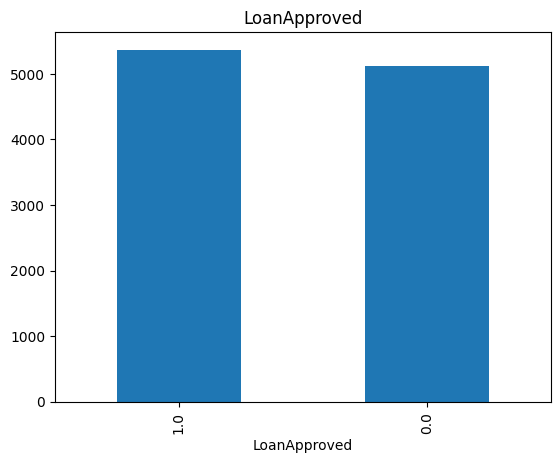

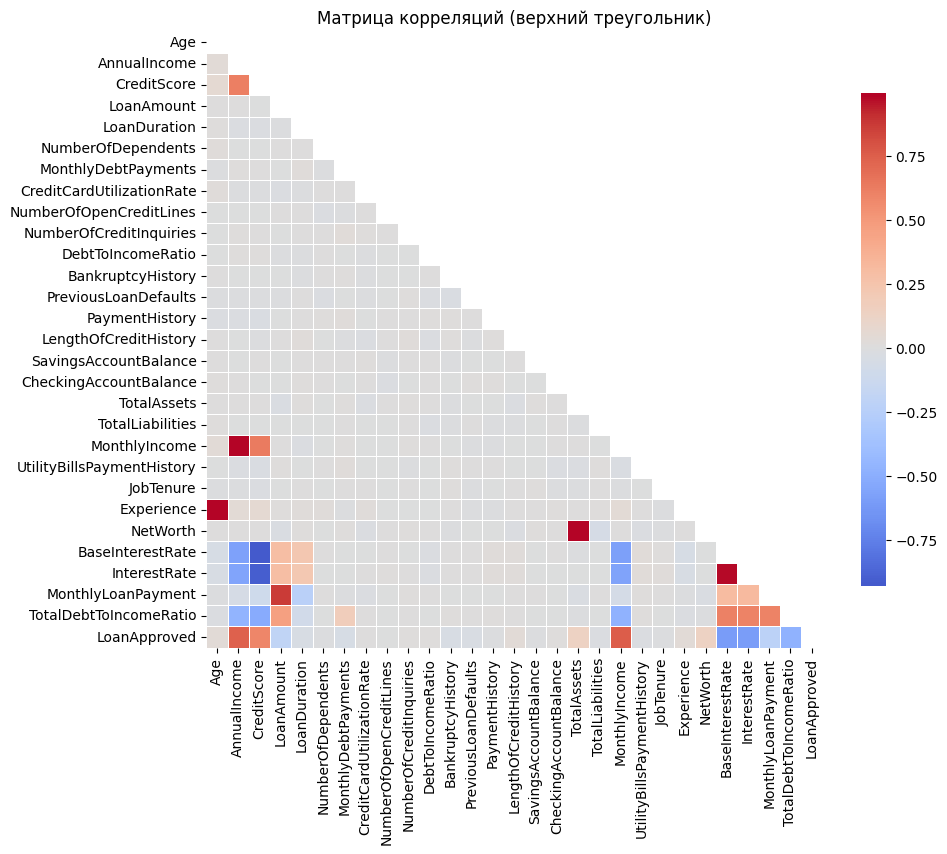



Топ-5 признаков по |корреляции| с LoanApproved:
MonthlyIncome       0.754853
AnnualIncome        0.743034
BaseInterestRate    0.605164
InterestRate        0.599180
CreditScore         0.581812
Name: LoanApproved, dtype: float64




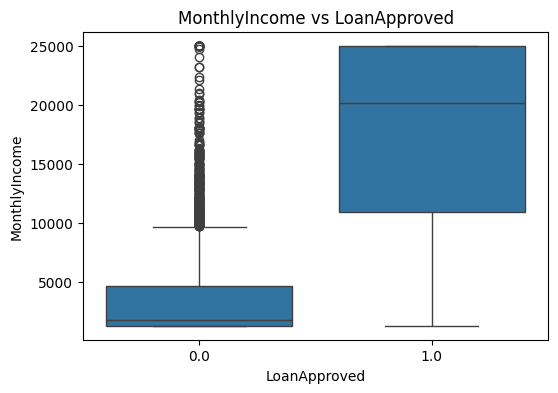

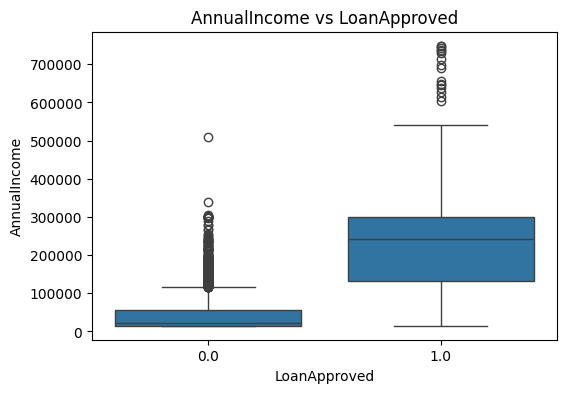

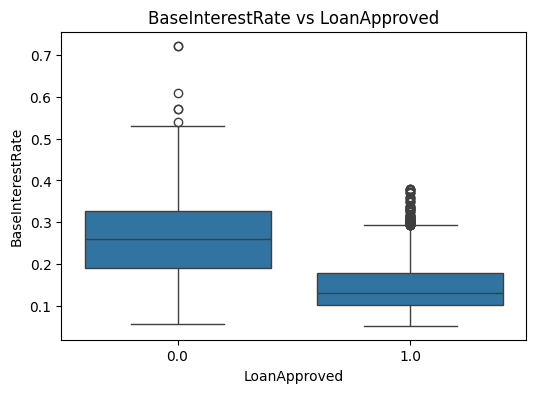

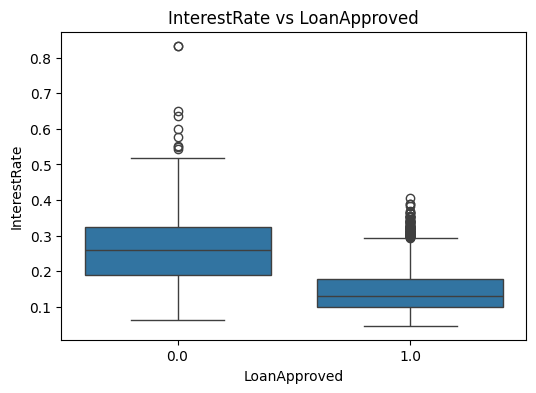

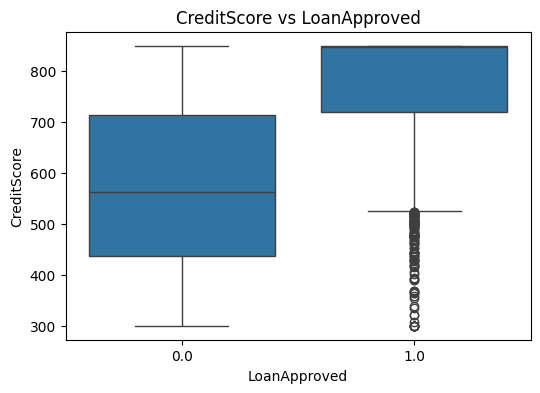

In [23]:
print(train_df['LoanApproved'].value_counts(normalize=True), end="\n\n")
train_df['LoanApproved'].value_counts().plot(kind='bar')
plt.title('LoanApproved')
plt.show()

print()
print()

num_cols = train_df.select_dtypes(include=[np.number]).drop(columns=['ID'], errors='ignore')
corr = num_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, square=True, linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Матрица корреляций (верхний треугольник)')
plt.show()

print()
print()

corr_with_target = corr['LoanApproved'].drop('LoanApproved').abs().sort_values(ascending=False)
top_features = corr_with_target.head().index.tolist()
print("Топ-5 признаков по |корреляции| с LoanApproved:")
print(corr_with_target.head())

print()
print()

for feat in top_features[:5]:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=train_df, x='LoanApproved', y=feat)
    plt.title(f'{feat} vs LoanApproved')
    plt.show()
    print()
    print()



## Подготовить на основе выводов данные для обучения.

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

train_df_clean = train_df.dropna(subset=['LoanApproved']).copy()
train_df_clean['LoanApproved'] = train_df_clean['LoanApproved'].astype(int)

print(f"Размер train_df после удаления NaN: {train_df_clean.shape}")

X_train_raw = train_df_clean.drop(columns=['ID', 'LoanApproved'], errors='ignore')
X_test_raw = test_df.drop(columns=['ID'], errors='ignore')

df_all = pd.concat([X_train_raw, X_test_raw], axis=0).reset_index(drop=True)

cat_cols = df_all.select_dtypes(include=['object']).columns.tolist()
num_cols = df_all.select_dtypes(include=[np.number]).columns.tolist()

if cat_cols:
    imputer_cat = SimpleImputer(strategy='most_frequent')
    df_all[cat_cols] = imputer_cat.fit_transform(df_all[cat_cols])

if num_cols:
    imputer_num = SimpleImputer(strategy='median')
    df_all[num_cols] = imputer_num.fit_transform(df_all[num_cols])

label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_all[col] = le.fit_transform(df_all[col].astype(str))
    label_encoders[col] = le

n_train = len(X_train_raw)
X = df_all.iloc[:n_train].reset_index(drop=True)
X_test_final = df_all.iloc[n_train:].reset_index(drop=True)
y = train_df_clean['LoanApproved'].reset_index(drop=True)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"y_train distribution:\n{y_train.value_counts(normalize=True)}")

Размер train_df после удаления NaN: (10487, 35)
X_train shape: (8389, 34)
y_train distribution:
LoanApproved
1    0.511742
0    0.488258
Name: proportion, dtype: float64


## Реализация метрик

In [35]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc)

class MyMetrics:
    @staticmethod
    def accuracy(y_true, y_pred):
        return np.mean(y_true == y_pred)

    @staticmethod
    def precision(y_true, y_pred):
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        return tp / (tp + fp) if (tp + fp) > 0 else 0.0

    @staticmethod
    def recall(y_true, y_pred):
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        return tp / (tp + fn) if (tp + fn) > 0 else 0.0

    @staticmethod
    def f1(y_true, y_pred):
        p = MyMetrics.precision(y_true, y_pred)
        r = MyMetrics.recall(y_true, y_pred)
        return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

    @staticmethod
    def roc_auc(y_true, y_prob):
        pos = y_prob[y_true == 1]
        neg = y_prob[y_true == 0]
        if len(pos) == 0 or len(neg) == 0:
            return 0.5
        return np.mean(pos[:, None] > neg)

    @staticmethod
    def pr_auc(y_true, y_prob):
        desc_idx = np.argsort(-y_prob)
        y_true_sorted = y_true[desc_idx]
        n_pos = np.sum(y_true)
        if n_pos == 0:
            return 0.0

        tp = fp = 0
        precisions = [1.0]
        recalls = [0.0]

        for label in y_true_sorted:
            if label == 1:
                tp += 1
            else:
                fp += 1
            precisions.append(tp / (tp + fp))
            recalls.append(tp / n_pos)
        return np.trapezoid(precisions, recalls)

y_true = np.array([1, 0, 1, 1, 0, 1, 0, 0, 1, 1])
y_pred = np.array([1, 0, 1, 0, 0, 1, 0, 0, 1, 1])
y_prob = np.array([0.9, 0.1, 0.8, 0.75, 0.2, 0.85, 0.3, 0.15, 0.95, 0.7])

print("--- Сравнение с sklearn ---")
print(f"Accuracy:  My={MyMetrics.accuracy(y_true, y_pred):.4f}, Sklearn={accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: My={MyMetrics.precision(y_true, y_pred):.4f}, Sklearn={precision_score(y_true, y_pred):.4f}")
print(f"ROC-AUC:   My={MyMetrics.roc_auc(y_true, y_prob):.4f}, Sklearn={roc_auc_score(y_true, y_prob):.4f}")
print(f"F1-score:  My={MyMetrics.f1(y_true, y_pred):.4f}, Sklearn={f1_score(y_true, y_pred):.4f}")
print(f"Recall:    My={MyMetrics.recall(y_true, y_pred):.4f}, Sklearn={recall_score(y_true, y_pred):.4f}")

prec, rec, _ = precision_recall_curve(y_true, y_prob)
pr_auc_sk = auc(rec, prec)
print(f"PR-AUC:    My={MyMetrics.pr_auc(y_true, y_prob):.4f}, Sklearn={pr_auc_sk:.4f}")

--- Сравнение с sklearn ---
Accuracy:  My=0.9000, Sklearn=0.9000
Precision: My=1.0000, Sklearn=1.0000
ROC-AUC:   My=1.0000, Sklearn=1.0000
F1-score:  My=0.9091, Sklearn=0.9091
Recall:    My=0.8333, Sklearn=0.8333
PR-AUC:    My=1.0000, Sklearn=1.0000


Собственные реализации метрик совпадают с эталонными из sklearn.

##Реализовать класс бэггинга, который для обучения методом fit обучает n базовых моделей b.

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.base import clone
import numpy as np

class MyBaggingClassifier:
    def __init__(self, base_estimator=None, n_estimators=10, random_state=42):
        self.base_estimator = base_estimator if base_estimator else DecisionTreeClassifier()
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.models = []

    def fit(self, X, y):
        self.models = []
        rng = np.random.default_rng(self.random_state)
        X_arr = np.asarray(X)
        y_arr = np.asarray(y)
        n_samples = X_arr.shape[0]

        for _ in range(self.n_estimators):
            indices = rng.choice(n_samples, size=n_samples, replace=True)
            X_sample = X_arr[indices]
            y_sample = y_arr[indices]

            model = clone(self.base_estimator)
            model.fit(X_sample, y_sample)
            self.models.append(model)

        return self

    def predict_proba(self, X):
        X_arr = np.asarray(X)
        probas = [model.predict_proba(X_arr) for model in self.models]
        return np.mean(probas, axis=0)

    def predict(self, X):
        probas = self.predict_proba(X)
        return np.argmax(probas, axis=1)


# --- Сравнение ---
print("Обучаем MyBaggingClassifier...")
my_bagging = MyBaggingClassifier(
    base_estimator=DecisionTreeClassifier(max_depth=10, random_state=42),
    n_estimators=50,
    random_state=42
)
my_bagging.fit(X_train, y_train)

y_pred_my = my_bagging.predict(X_val)
y_prob_my = my_bagging.predict_proba(X_val)[:, 1]

print("Обучаем sklearn BaggingClassifier...")
sk_bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10, random_state=42),
    n_estimators=50,
    random_state=42,
    n_jobs=-1  # ускорение
)
sk_bagging.fit(X_train, y_train)

y_pred_sk = sk_bagging.predict(X_val)
y_prob_sk = sk_bagging.predict_proba(X_val)[:, 1]

print("\n--- Результаты ---")
print(f"My Bagging ROC-AUC:      {roc_auc_score(y_val, y_prob_my):.4f}")
print(f"Sklearn Bagging ROC-AUC: {roc_auc_score(y_val, y_prob_sk):.4f}")
print(f"My Bagging Accuracy:     {accuracy_score(y_val, y_pred_my):.4f}")
print(f"Sklearn Bagging Accuracy: {accuracy_score(y_val, y_pred_sk):.4f}")

Обучаем MyBaggingClassifier...
Обучаем sklearn BaggingClassifier...

--- Результаты ---
My Bagging ROC-AUC:      0.9779
Sklearn Bagging ROC-AUC: 0.9776
My Bagging Accuracy:     0.9199
Sklearn Bagging Accuracy: 0.9194


## Сравнить результаты работы алгоритмов градиентного бустинга: реализация из sklearn, LightGBM, XGBoost, CatBoost. Выбрать алгоритм с лучшей метрикой на данных.

Training my model...
Training sklearn model...

Results comparison:
AUC-ROC:
My: 0.9723634631052142
Sklearn: 0.9788402365572626

AUC-PR:
My: 0.9753997890031352
Sklearn: 0.980906243091609

Accuracy:
My: 0.9108674928503336
Sklearn: 0.9232602478551001

Precision:
My: 0.9065077910174152
Sklearn: 0.9230769230769231

Recall:
My: 0.9208566108007449
Sklearn: 0.9273743016759777

F1:
My: 0.9136258660508083
Sklearn: 0.9252206223873666


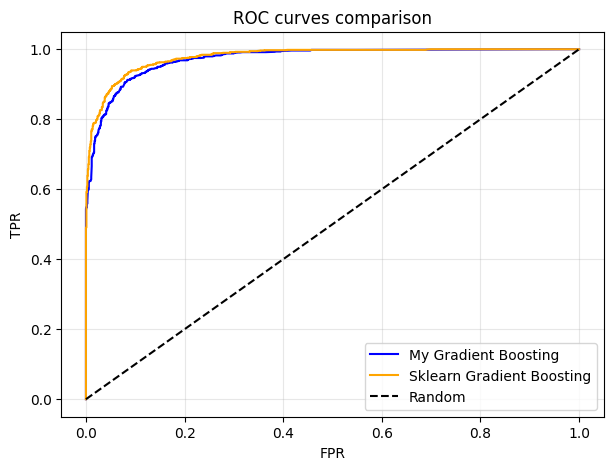

In [34]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_curve

def sigmoid_func(x):
    return 1.0 / (1.0 + np.exp(-x))

class MyGradientBoostingClassifier:
    def __init__(self, n_trees=50, lr=0.1, tree_depth=3, seed=42):
        self.n_trees = n_trees
        self.lr = lr
        self.tree_depth = tree_depth
        self.seed = seed
        self.trees = []
        self.start_value = 0.0

    def fit(self, X, y):
        np.random.seed(self.seed)
        self.trees = []

        y_mean = np.mean(y)
        y_mean = np.clip(y_mean, 1e-7, 1 - 1e-7)
        self.start_value = np.log(y_mean / (1 - y_mean))

        current_pred = np.full(len(y), self.start_value)

        for i in range(self.n_trees):
            prob_pred = sigmoid_func(current_pred)
            residuals = y - prob_pred

            tree = DecisionTreeRegressor(max_depth=self.tree_depth, random_state=self.seed + i)
            tree.fit(X, residuals)
            self.trees.append(tree)

            tree_pred = tree.predict(X)
            current_pred += self.lr * tree_pred

        return self

    def predict_proba(self, X):
        pred = np.full(X.shape[0], self.start_value)
        for tree in self.trees:
            pred += self.lr * tree.predict(X)
        prob = sigmoid_func(pred)
        result = np.zeros((len(prob), 2))
        result[:, 0] = 1 - prob
        result[:, 1] = prob
        return result

    def predict(self, X):
        prob = self.predict_proba(X)[:, 1]
        return (prob > 0.5).astype(int)

print('Training my model...')
my_gb = MyGradientBoostingClassifier(n_trees=50, lr=0.1, tree_depth=3, seed=42)
my_gb.fit(X_train, y_train)
my_gb_probs = my_gb.predict_proba(X_val)[:, 1]
my_gb_preds = my_gb.predict(X_val)

print('Training sklearn model...')
sk_gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.1, max_depth=3, random_state=42)
sk_gb.fit(X_train, y_train)
sk_gb_probs = sk_gb.predict_proba(X_val)[:, 1]
sk_gb_preds = sk_gb.predict(X_val)

y_val_np = y_val.values if hasattr(y_val, 'values') else np.array(y_val)
my_gb_preds_np = my_gb_preds
sk_gb_preds_np = sk_gb_preds

print('\nResults comparison:')
print('AUC-ROC:')
print('My:', MyMetrics.roc_auc(y_val_np, my_gb_probs))
print('Sklearn:', MyMetrics.roc_auc(y_val_np, sk_gb_probs))

print('\nAUC-PR:')
print('My:', MyMetrics.pr_auc(y_val_np, my_gb_probs))
print('Sklearn:', MyMetrics.pr_auc(y_val_np, sk_gb_probs))

print('\nAccuracy:')
print('My:', MyMetrics.accuracy(y_val_np, my_gb_preds_np))
print('Sklearn:', MyMetrics.accuracy(y_val_np, sk_gb_preds_np))

print('\nPrecision:')
print('My:', MyMetrics.precision(y_val_np, my_gb_preds_np))
print('Sklearn:', MyMetrics.precision(y_val_np, sk_gb_preds_np))

print('\nRecall:')
print('My:', MyMetrics.recall(y_val_np, my_gb_preds_np))
print('Sklearn:', MyMetrics.recall(y_val_np, sk_gb_preds_np))

print('\nF1:')
print('My:', MyMetrics.f1(y_val_np, my_gb_preds_np))
print('Sklearn:', MyMetrics.f1(y_val_np, sk_gb_preds_np))

fpr_my, tpr_my, _ = roc_curve(y_val_np, my_gb_probs)
fpr_sk, tpr_sk, _ = roc_curve(y_val_np, sk_gb_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr_my, tpr_my, label='My Gradient Boosting', color='blue')
plt.plot(fpr_sk, tpr_sk, label='Sklearn Gradient Boosting', color='orange')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC curves comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Сравнить результаты работы алгоритмов градиентного бустинга: реализация из sklearn, LightGBM, XGBoost, CatBoost. Выбрать алгоритм с лучшей метрикой на данных.

In [37]:
#!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.0 MB/s eta 0:00:00


In [39]:
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from sklearn.metrics import roc_auc_score

params = {
    'n_estimators': 100,
    'max_depth': 6,
    'random_state': 42
}

# LightGBM
print("Training LightGBM...")
lgb_model = lgb.LGBMClassifier(**params, verbose=-1)
lgb_model.fit(X_train, y_train)
y_prob_lgb = lgb_model.predict_proba(X_val)[:, 1]
lgb_score = roc_auc_score(y_val, y_prob_lgb)
print(f"LightGBM ROC-AUC: {lgb_score:.4f}")

# XGBoost
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    **params,
    eval_metric='logloss')
xgb_model.fit(X_train, y_train)
y_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]
xgb_score = roc_auc_score(y_val, y_prob_xgb)
print(f"XGBoost ROC-AUC:  {xgb_score:.4f}")

# CatBoost
print("Training CatBoost...")
cb_model = cb.CatBoostClassifier(**params, verbose=0)
cb_model.fit(X_train, y_train)
y_prob_cb = cb_model.predict_proba(X_val)[:, 1]
cb_score = roc_auc_score(y_val, y_prob_cb)
print(f"CatBoost ROC-AUC: {cb_score:.4f}")

# Вывод лучшей модели
scores = {'LightGBM': lgb_score, 'XGBoost': xgb_score, 'CatBoost': cb_score}
best_model = max(scores, key=scores.get)
print(f"\nЛучшая модель: {best_model} (ROC-AUC = {scores[best_model]:.4f})")

Training LightGBM...
LightGBM ROC-AUC: 0.9808
Training XGBoost...
XGBoost ROC-AUC:  0.9806
Training CatBoost...
CatBoost ROC-AUC: 0.9822

Лучшая модель: CatBoost (ROC-AUC = 0.9822)


## Подобрать оптимальные гиперпараметры для лучшей модели с помощью Optuna.

In [41]:
#!pip install optuna lightgbm xgboost catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 4.4 MB/s eta 0:00:00


In [44]:
import optuna
from sklearn.metrics import roc_auc_score

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_state': 42,
        'verbose': 0
    }

    model = cb.CatBoostClassifier(**params)
    model.fit(X_train, y_train, eval_set=(X_val, y_val), early_stopping_rounds=30, verbose=0)

    preds = model.predict_proba(X_val)[:, 1]
    return roc_auc_score(y_val, preds)

print("\n--- Запуск Optuna для CatBoost ---")
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=30, show_progress_bar=True)

print('\nОптимизация завершена!')
print('Best trial:')
trial = study.best_trial
print(f'  ROC-AUC: {trial.value:.4f}')
print('  Параметры:')
for key, value in trial.params.items():
    print(f'    {key}: {value}')

X_full_train = pd.concat([X_train, X_val], ignore_index=True)
y_full_train = pd.concat([y_train, y_val], ignore_index=True)

best_params = trial.params
best_params.update({
    'random_state': 42,
    'verbose': 0,
    'iterations': trial.params['iterations']})

final_model = cb.CatBoostClassifier(**best_params)
final_model.fit(X_full_train, y_full_train)


[I 2025-12-23 12:14:11,208] A new study created in memory with name: no-name-487bb7d9-ddaa-434c-8221-829caac851c1



--- Запуск Optuna для CatBoost ---


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-23 12:14:15,663] Trial 0 finished with value: 0.9810697814827748 and parameters: {'iterations': 163, 'learning_rate': 0.1800348249013269, 'depth': 8, 'l2_leaf_reg': 3.0171430925473186}. Best is trial 0 with value: 0.9810697814827748.
[I 2025-12-23 12:14:21,404] Trial 1 finished with value: 0.9798759020018623 and parameters: {'iterations': 261, 'learning_rate': 0.023022719759595373, 'depth': 4, 'l2_leaf_reg': 7.917086871947795}. Best is trial 0 with value: 0.9810697814827748.
[I 2025-12-23 12:14:28,365] Trial 2 finished with value: 0.9803314493133147 and parameters: {'iterations': 489, 'learning_rate': 0.014260376480395114, 'depth': 4, 'l2_leaf_reg': 6.645057952254136}. Best is trial 0 with value: 0.9810697814827748.
[I 2025-12-23 12:14:32,251] Trial 3 finished with value: 0.9821709148044693 and parameters: {'iterations': 147, 'learning_rate': 0.1273797283192214, 'depth': 7, 'l2_leaf_reg': 6.398718958357326}. Best is trial 3 with value: 0.9821709148044693.
[I 2025-12-23 12:14

In [43]:
y_pred_final = final_model.predict(X_val)
y_prob_final = final_model.predict_proba(X_val)[:, 1]

print("\n" + "="*60)
print("ФИНАЛЬНЫЕ МЕТРИКИ ЛУЧШЕЙ МОДЕЛИ")
print("="*60)
print(f"Accuracy:  {MyMetrics.accuracy(y_val.values, y_pred_final):.4f}")
print(f"Precision: {MyMetrics.precision(y_val.values, y_pred_final):.4f}")
print(f"Recall:    {MyMetrics.recall(y_val.values, y_pred_final):.4f}")
print(f"F1-score:  {MyMetrics.f1(y_val.values, y_pred_final):.4f}")
print(f"ROC-AUC:   {MyMetrics.roc_auc(y_val.values, y_prob_final):.4f}")
print(f"PR-AUC:    {MyMetrics.pr_auc(y_val.values, y_prob_final):.4f}")

print(f"\nСравнение со sklearn:")
print(f"ROC-AUC sklearn: {roc_auc_score(y_val, y_prob_final):.4f}")
from sklearn.metrics import precision_recall_curve, auc
prec, rec, _ = precision_recall_curve(y_val, y_prob_final)
pr_auc_sk = auc(rec, prec)
print(f"PR-AUC sklearn:  {pr_auc_sk:.4f}")
print("="*60)

test_preds = final_model.predict_proba(X_test_final)[:, 1]

submission = pd.DataFrame({
    'ID': test_df['ID'].values,  # ← используем test_df, который уже в памяти
    'LoanApproved': test_preds})

submission.to_csv('submission_lab2.csv', index=False)
print(f"Размер файла: {submission.shape}")
print("\nПримеры предсказаний:")
print(submission.head(10))


ФИНАЛЬНЫЕ МЕТРИКИ ЛУЧШЕЙ МОДЕЛИ
Accuracy:  0.9967
Precision: 0.9981
Recall:    0.9953
F1-score:  0.9967
ROC-AUC:   1.0000
PR-AUC:    1.0000

Сравнение со sklearn:
ROC-AUC sklearn: 1.0000
PR-AUC sklearn:  1.0000
Размер файла: (5000, 2)

Примеры предсказаний:
   ID  LoanApproved
0   0      0.999361
1   1      0.007545
2   2      0.999477
3   3      0.998451
4   4      0.994451
5   5      0.001157
6   6      0.999796
7   7      0.998065
8   8      0.808629
9   9      0.000185
